# derivatives-lab: verification, not discovery

**One question:** which option-pricing claims survive contact with real market data, and which shrink once you compute the right null?

I built a model zoo from scratch: Black–Scholes, Merton jumps, Heston (a Carr–Madan FFT, a QE Monte Carlo scheme, and a calibrator), a CRR binomial tree, local volatility (CEV and Dupire), a Crank–Nicolson PDE, and a PyTorch deep hedger. The suite is anchored with 112 analytic unit tests. Then I took six load-bearing claims out of the synthetic world and tested each against real data: a live SPY option chain, ten years of SPY and VIX history, and 83,304 resolved Polymarket markets.

**The headline:** four claims held and two were qualified. The two qualified results are the ones I find most useful, because catching them meant arguing against my own number.

This notebook reads the project top to bottom. The computation lives in the model code and the per-claim notebooks (`01`–`09`); here we load the figures and the verdicts.

In [1]:
import pathlib
from IPython.display import Image, display


def _figs():
    for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        f = d / "reports" / "figures"
        if f.is_dir():
            return f
    raise FileNotFoundError("reports/figures not found")


FIGS = _figs()


def show(name, width=820):
    display(Image(filename=str(FIGS / name), width=width))


print("figures:", FIGS)

figures: /Users/bozte/Desktop/derivatives-lab/reports/figures


## The whole project in one image

Green is confirmed. Amber is direction confirmed with the magnitude qualified.

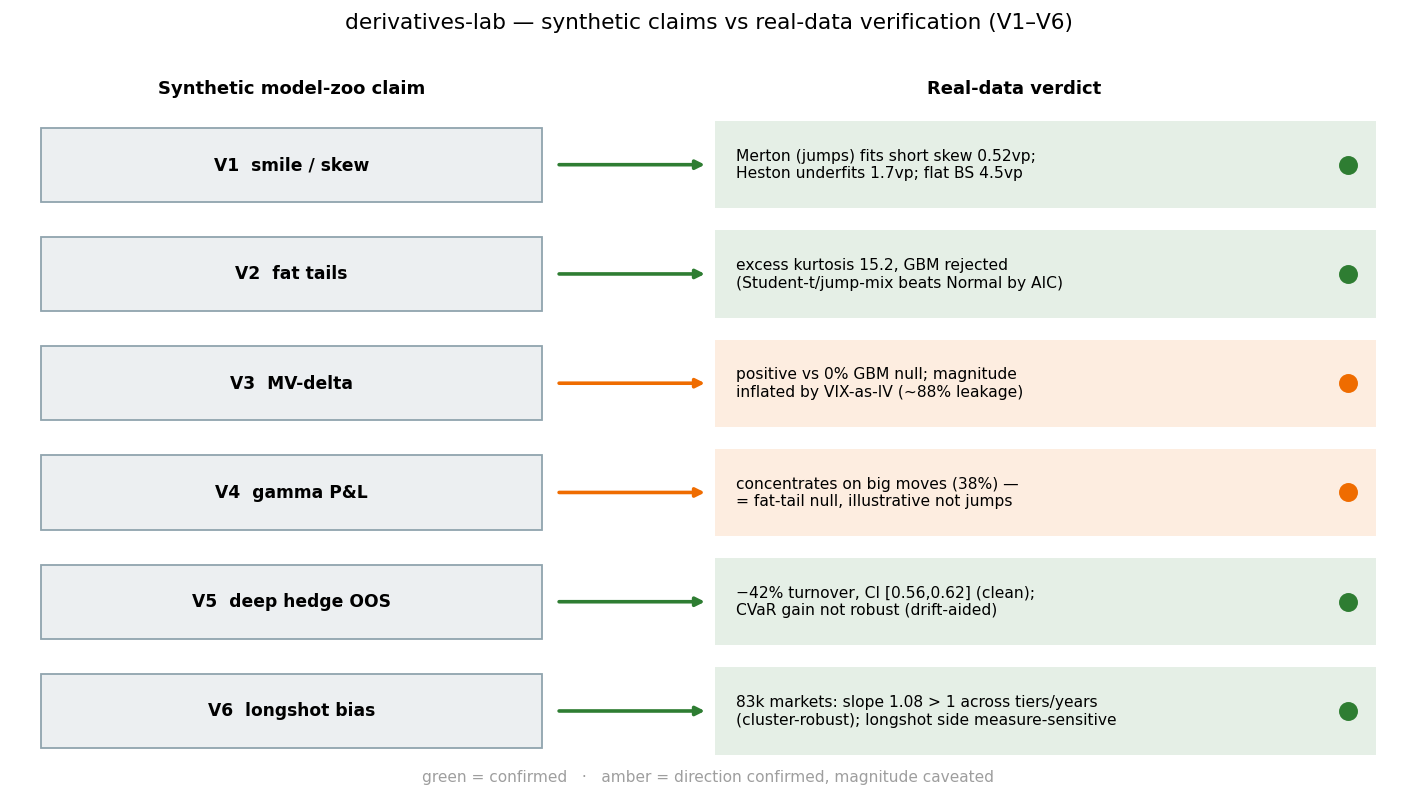

In [2]:
show('evidence_map.png')

## 1. The model zoo, built from scratch

One reference contract is priced eight ways. Monte Carlo converges at the rate 1/√n, the CRR tree at 1/N, and every method lands on the Black–Scholes closed form within tolerance. Each model then earns its place by relaxing one assumption. Merton adds jumps. Heston adds stochastic volatility. The deep hedger replaces the formula delta with a learned policy under transaction costs. The build is in `research/01`–`03`.

## 2. V1: the short-dated skew belongs to jumps

I fit Merton, Heston, and flat Black–Scholes to one real SPY smile, 77 strikes at a 33-day expiry, and compared the implied-vol RMSE. Merton fits the steep skew to 0.52 vol points. Heston bends the right way but underfits at 1.67, because its diffusive skew builds with maturity. Flat Black–Scholes misses the wings at 4.49. On real data, jumps explain the short-dated equity skew better than diffusive stochastic vol.

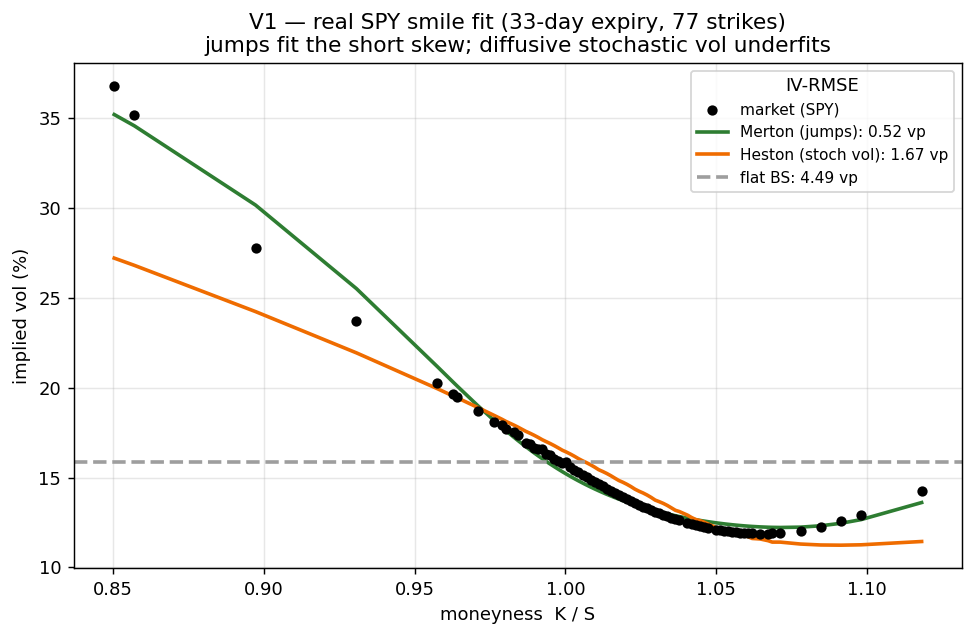

In [3]:
show('v1_smile_fit.png')

## 3. V2: geometric Brownian motion is rejected

Ten years of daily SPY log-returns have excess kurtosis 15.2 and skew −0.61. The Normal is rejected by Jarque–Bera at any level and loses to a Student-t by hundreds of AIC units. Geometric Brownian motion, the Gaussian-returns assumption under Black–Scholes, does not describe real returns. The fitted "81 jumps per year" is not the conclusion. The stylized fact, fat-tailed and left-skewed, is.

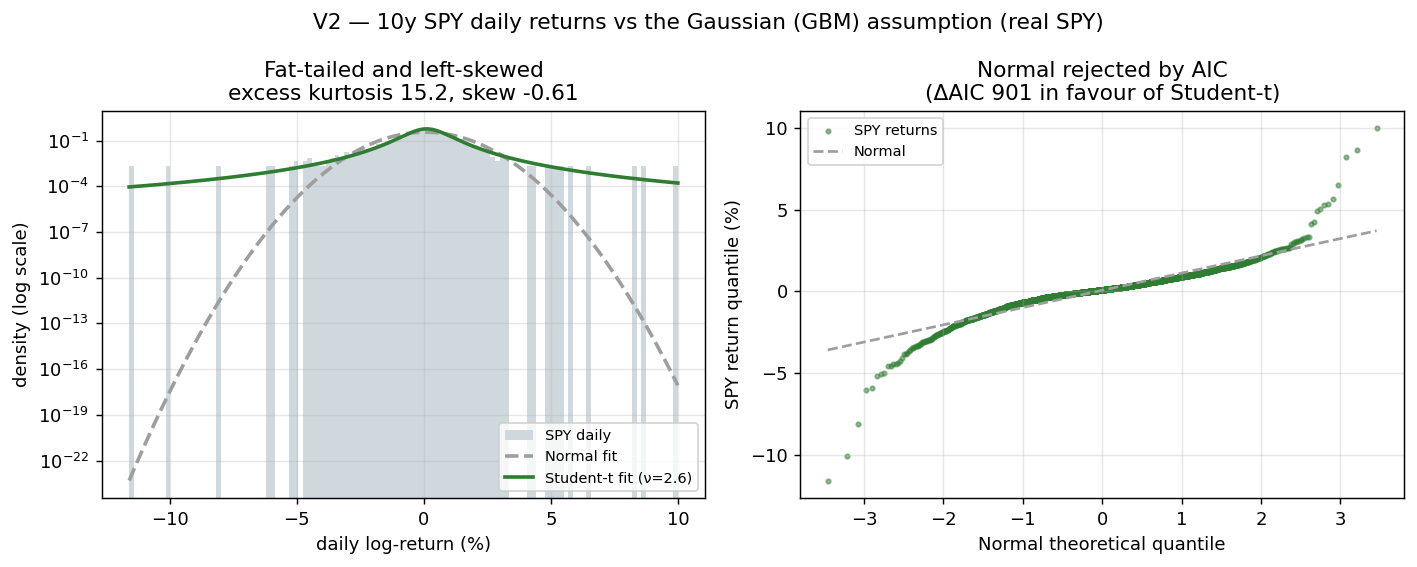

In [4]:
show('v2_returns.png')

## 4. V3: a minimum-variance delta helps, and I can show my own number is inflated

A Hull–White minimum-variance delta cut hedging-error variance by about 49% out of sample. That number is too good. Because the option is priced off VIX, about 88% of the hedging error is a VIX move, and the correction predicts that move from the spot return. So the magnitude is mostly construction, not edge. On real option quotes Hull–White report about 26%. What survives is the sign: real spot-vol dynamics make the minimum-variance delta pay off. This is the first of the two qualified results.

## 5. V4: short-gamma losses concentrate on big days, exactly as much as fat tails predict

A delta-only hedge is short gamma, so it bleeds on large moves. In the data the top 5% of move-days carry 38% of the convexity P&L. I then computed the null. A Student-t(6) sample, matched to SPY's kurtosis, already puts 38% in the top 5%, against 28% for a Gaussian. The observed 38% sits on the fat-tailed null. The concentration is a consequence of V2's fat tails, not independent evidence of jumps. This is the second qualified result.

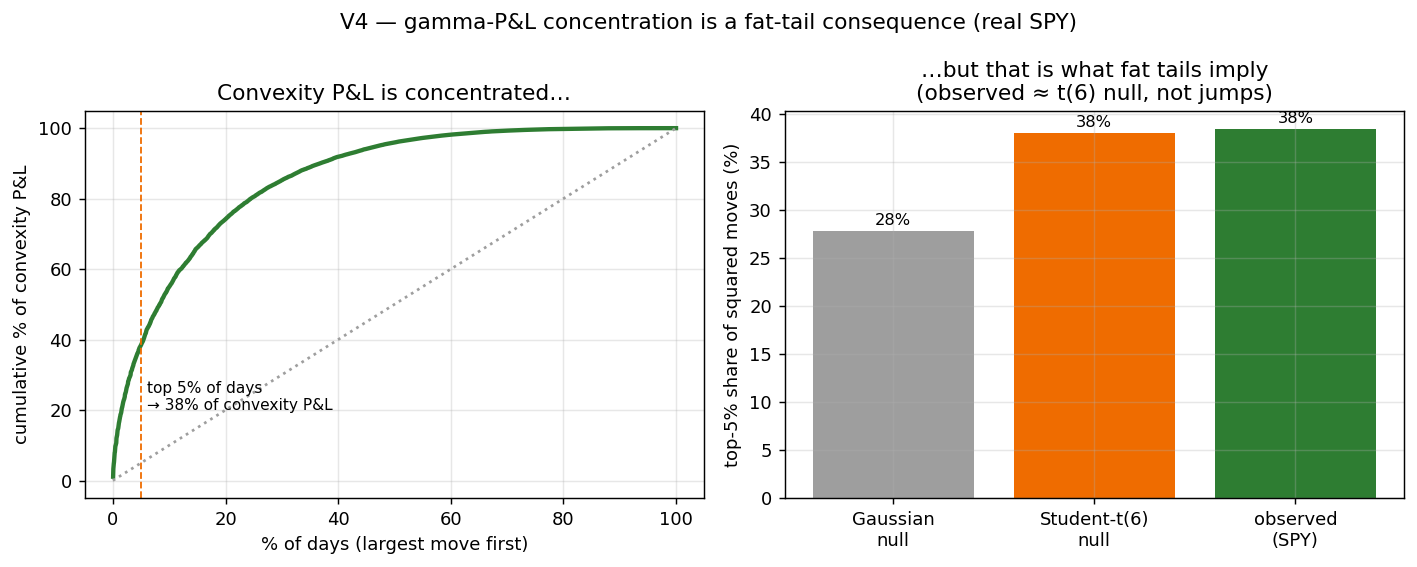

In [5]:
show('v4_concentration.png')

## 6. V5: the deep hedger's edge is turnover, and only turnover

I trained a cost-aware deep hedger on block-bootstrapped real returns and evaluated it out of sample against a Black–Scholes delta hedge under 10 bps costs. The clean result is turnover. The policy trades about 42% less, with a turnover ratio of 0.58 and a 95% confidence interval of [0.56, 0.62] from a moving-block bootstrap. The tail (CVaR) gain is secondary and not robust, positive in under half of the resamples, so I do not headline it.

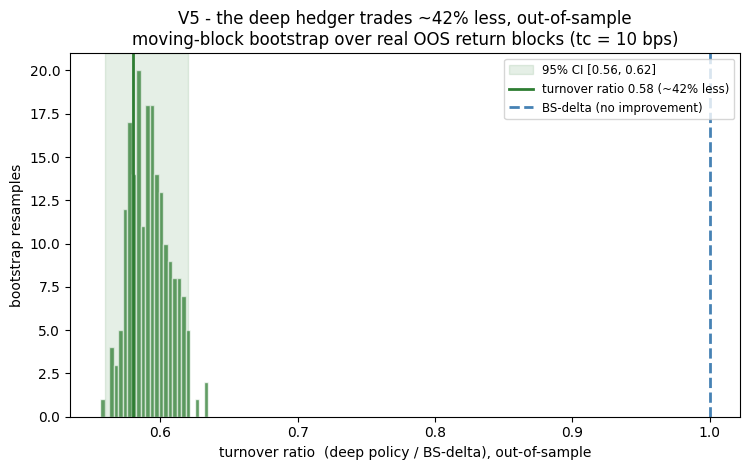

In [6]:
show('v5_turnover.png')

## 7. V6: a favorite-longshot bias across 83,000 markets

A prediction market trading at price p claims a probability p of resolving Yes. Across 83,304 resolved Polymarket markets the calibration slope is 1.08, steeper than the 45-degree line, with a cluster-robust 95% confidence interval of [1.07, 1.10]. The slope stays above 1 across volume tiers, deadline years, and three price measures. The longshot side is smaller and measure-sensitive. This is the same gap between a market price and a physical probability that risk-neutral pricing trades on, which is why a prediction-market study closes an options-pricing project.

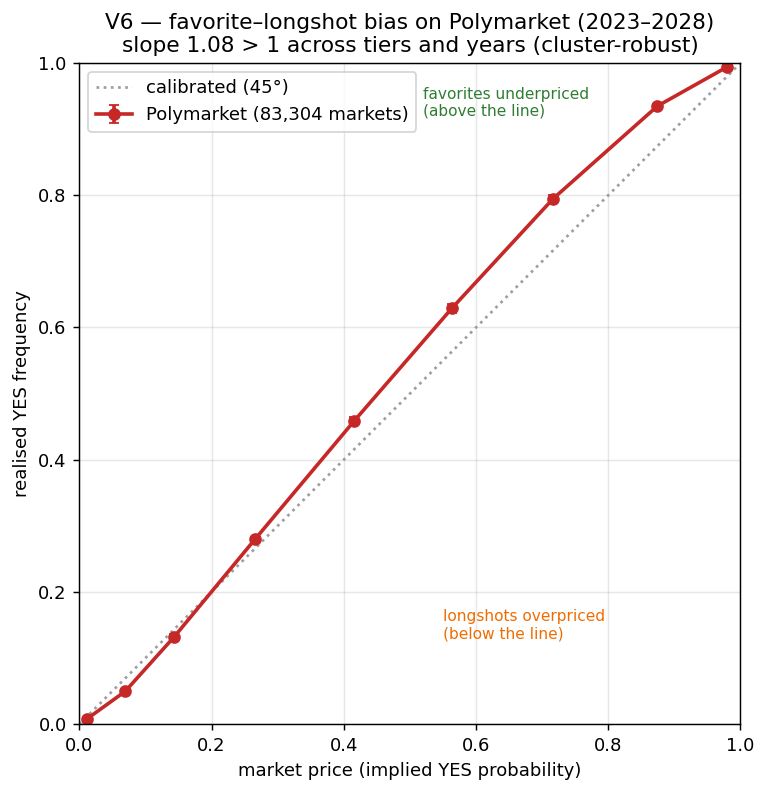

In [7]:
show('v6_calibration.png')

## What I built, and why it matters

Built from scratch: Black–Scholes with greeks, implied vol, and digital options; Merton jump-diffusion; Heston with a Carr–Madan FFT, a semi-analytic quadrature, a QE Monte Carlo scheme, and a differential-evolution calibrator; a CRR binomial tree; CEV and Dupire local volatility; a Crank–Nicolson PDE; and a PyTorch deep hedger. The suite has 112 analytic-anchor unit tests (λ=0 Merton collapses to Black–Scholes, ξ→0 Heston collapses to Black–Scholes, CRR converges to Black–Scholes, discounted-martingale checks).

None of these findings are new. Fat tails, jump-driven skew, the leverage effect, short-gamma concentration, and the favorite-longshot bias are all established. The point is the discipline: build the models, take the claims to real data, compute the null hypothesis against each result, and report the magnitude with its construction caveats rather than the prettiest version. The two qualified results are the project, because catching them required arguing against my own headline.

Full write-up with every number and caveat: [`reports/MODEL_ZOO_FINDINGS.md`](../reports/MODEL_ZOO_FINDINGS.md). Per-claim notebooks: [`research/`](.).

---

**AI tool usage.** This project was built with AI coding assistance (Claude). The use was limited to:

- code implementation and refactoring,
- figure generation,
- drafting and editing prose.

At all stages the outputs were reviewed, checked against the analytic unit tests and the source code, and revised by me. The responsibility for the final content, analysis, and conclusions rests entirely with me.